# annbatch revision

| section | comment | what is reported |
|---|---|---|
| 1 | R2 major 3 | training-loss reproduction of scDataset Fig. 6 (drug), and the final macro-F1 metrics |
| 2 | R3 comment 1 | the same curves faceted by chunk size, plus throughput vs chunk size |
| 3 | R3 comment 3 | minibatch diversity, the two parameter rules, and the few-epoch regime |
| 4 | R2 minor 3 | the four memmap baselines |
| 5 | R2 major 6 | pre-shuffling wall-clock for WGS and microscopy |


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import figures
from figures import RESULTS, FIGURES

figures.setup()
print("results:", RESULTS)

results: /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/annbatch_paper/revision/results


## 1. R2 major 3: model convergence

* reported panel: drug task
* cell line is learned equally well by every strategy -> serves
  as negative control
* `MappedCollection`: uniform random sampling -> equal to Random Sampling

wrote /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/annbatch_paper/revision/figures/revision_scdataset_fig6_drug.svg / .png


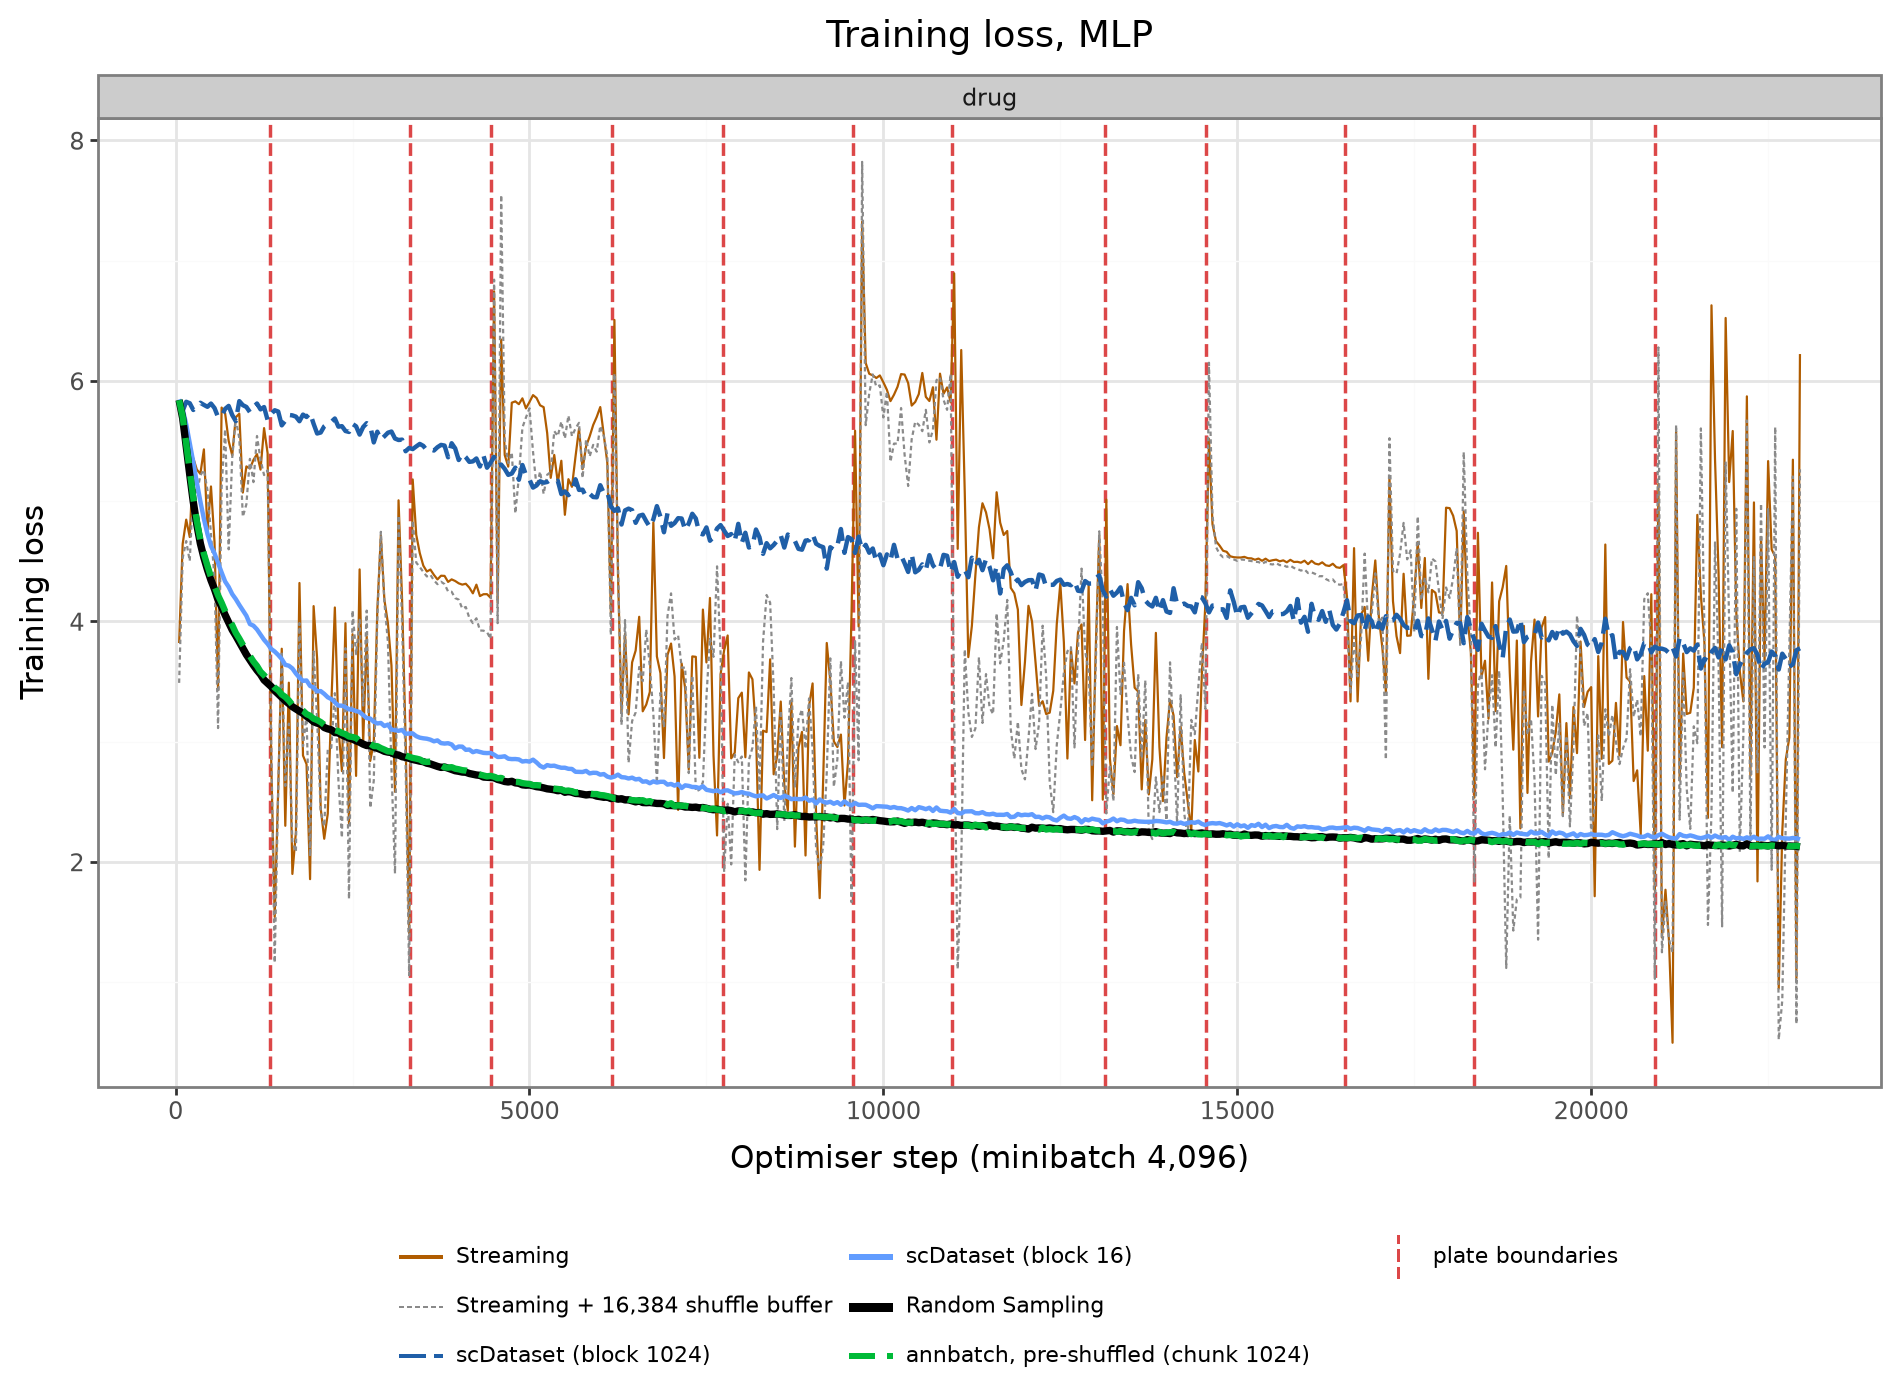

In [2]:
fig6 = figures.figure6_loss_curves()
p_drug = figures.plot_figure6(fig6, architecture="mlp", tasks=("drug",), ncol=1)
figures.save(p_drug, "revision_scdataset_fig6_drug", width=8.5, height=5.2)
p_drug

In [3]:
import pandas as pd
_drug = fig6[(fig6.architecture == "mlp") & (fig6.task == "drug")]
_lo = _drug.groupby("strategy", observed=True).loss.min().round(3)
_f1 = (figures.final_metrics(
           [r for r in figures.convergence_runs() if r["batch_size"] == 4096],
           "val_iid", "macro_f1")
       .query("architecture == 'mlp' and task == 'drug'")
       .groupby("strategy", observed=True).value.mean().round(4))
_name = _drug[["strategy", "display"]].drop_duplicates().set_index("strategy").display
_inv = pd.DataFrame({"min training loss": _lo, "held-out macro-F1": _f1}).dropna()
_inv.rename(index=_name).rename_axis(None).sort_values("min training loss")

,min training loss,held-out macro-F1
Streaming,0.496,0.0001
"Streaming + 16,384 shuffle buffer",0.522,0.0001
"annbatch, pre-shuffled (chunk 1024)",2.125,0.4717
Random Sampling,2.126,0.4731
scDataset (block 16),2.182,0.4493
scDataset (block 1024),3.561,0.1242


### Final metrics (the second half of R2 major 3)

In [4]:
runs = [r for r in figures.convergence_runs() if r["batch_size"] == 4096]
fm = figures.final_metrics(runs, "val_iid", "macro_f1")
_mlp = fm[fm.architecture == "mlp"]
# Mean and s.d. over seeds: the s.d. is what the non-inferiority margin rests on.
_agg = _mlp.groupby(["strategy", "task"]).value.agg(["mean", "std", "size"])
_agg.round(4).unstack("task")["mean"].round(4)

task,cell_line,drug,moa_broad,moa_fine
strategy,,,,
annbatch_pre_c1024,0.9390,0.4717,0.5461,0.4705
annbatch_pre_c128,0.9391,0.4720,0.5495,0.4692
annbatch_pre_c16,0.9391,0.4730,0.5518,0.4728
annbatch_pre_c256,0.9390,0.4705,0.5466,0.4744
annbatch_pre_c512,0.9389,0.4718,0.5515,0.4726
annbatch_pre_c64,0.9390,0.4726,0.5465,0.4729
annbatch_raw_c1024,0.9388,0.0700,0.2685,0.1394
annbatch_raw_c128,0.9390,0.2999,0.3722,0.2996
annbatch_raw_c16,0.9391,0.4425,0.5065,0.4074


In [5]:
# Drug, with the dispersion the margin argument uses, and the class counts.
print("classes per task:", runs[0]["tasks"])
_agg.xs("drug", level="task")[["mean", "std", "size"]].round(4).sort_values(
    "mean", ascending=False)

classes per task: {'cell_line': 50, 'drug': 380, 'moa_broad': 4, 'moa_fine': 27}


,mean,std,size
strategy,,,
random,0.4731,0.0006,3
annbatch_pre_c16,0.4730,0.0009,3
annbatch_pre_c64,0.4726,0.0004,3
annbatch_pre_c128,0.4720,0.0008,3
annbatch_pre_c512,0.4718,0.0014,3
annbatch_pre_c1024,0.4717,0.0009,3
annbatch_pre_c256,0.4705,0.0021,3
scdataset_b16_f32,0.4673,0.0002,3
scdataset_b16_f4,0.4493,0.0012,3


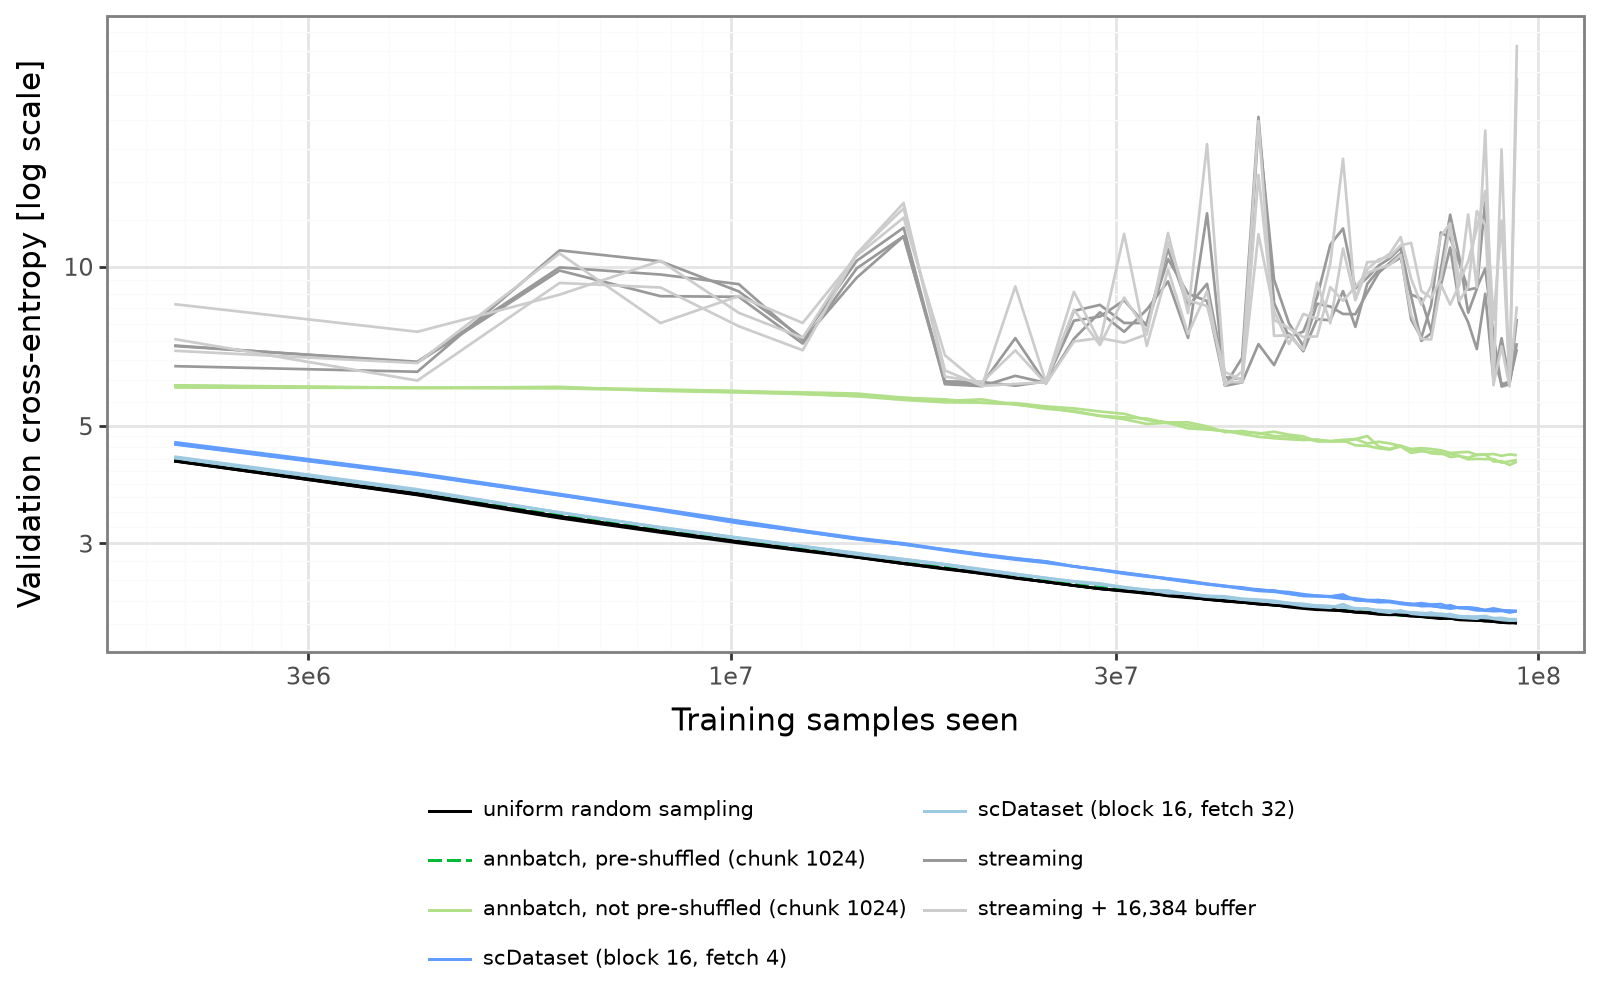

In [6]:
figures.plot_headline_curves(
    figures.validation_curves(runs, "mlp/drug", "val_iid", "loss"),
    ylabel="Validation cross-entropy", log_y=True)

## 2. R3 comment 1: the pre-shuffling trade-off

wrote /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/annbatch_paper/revision/figures/revision_fig6_chunk_sweep.svg / .png


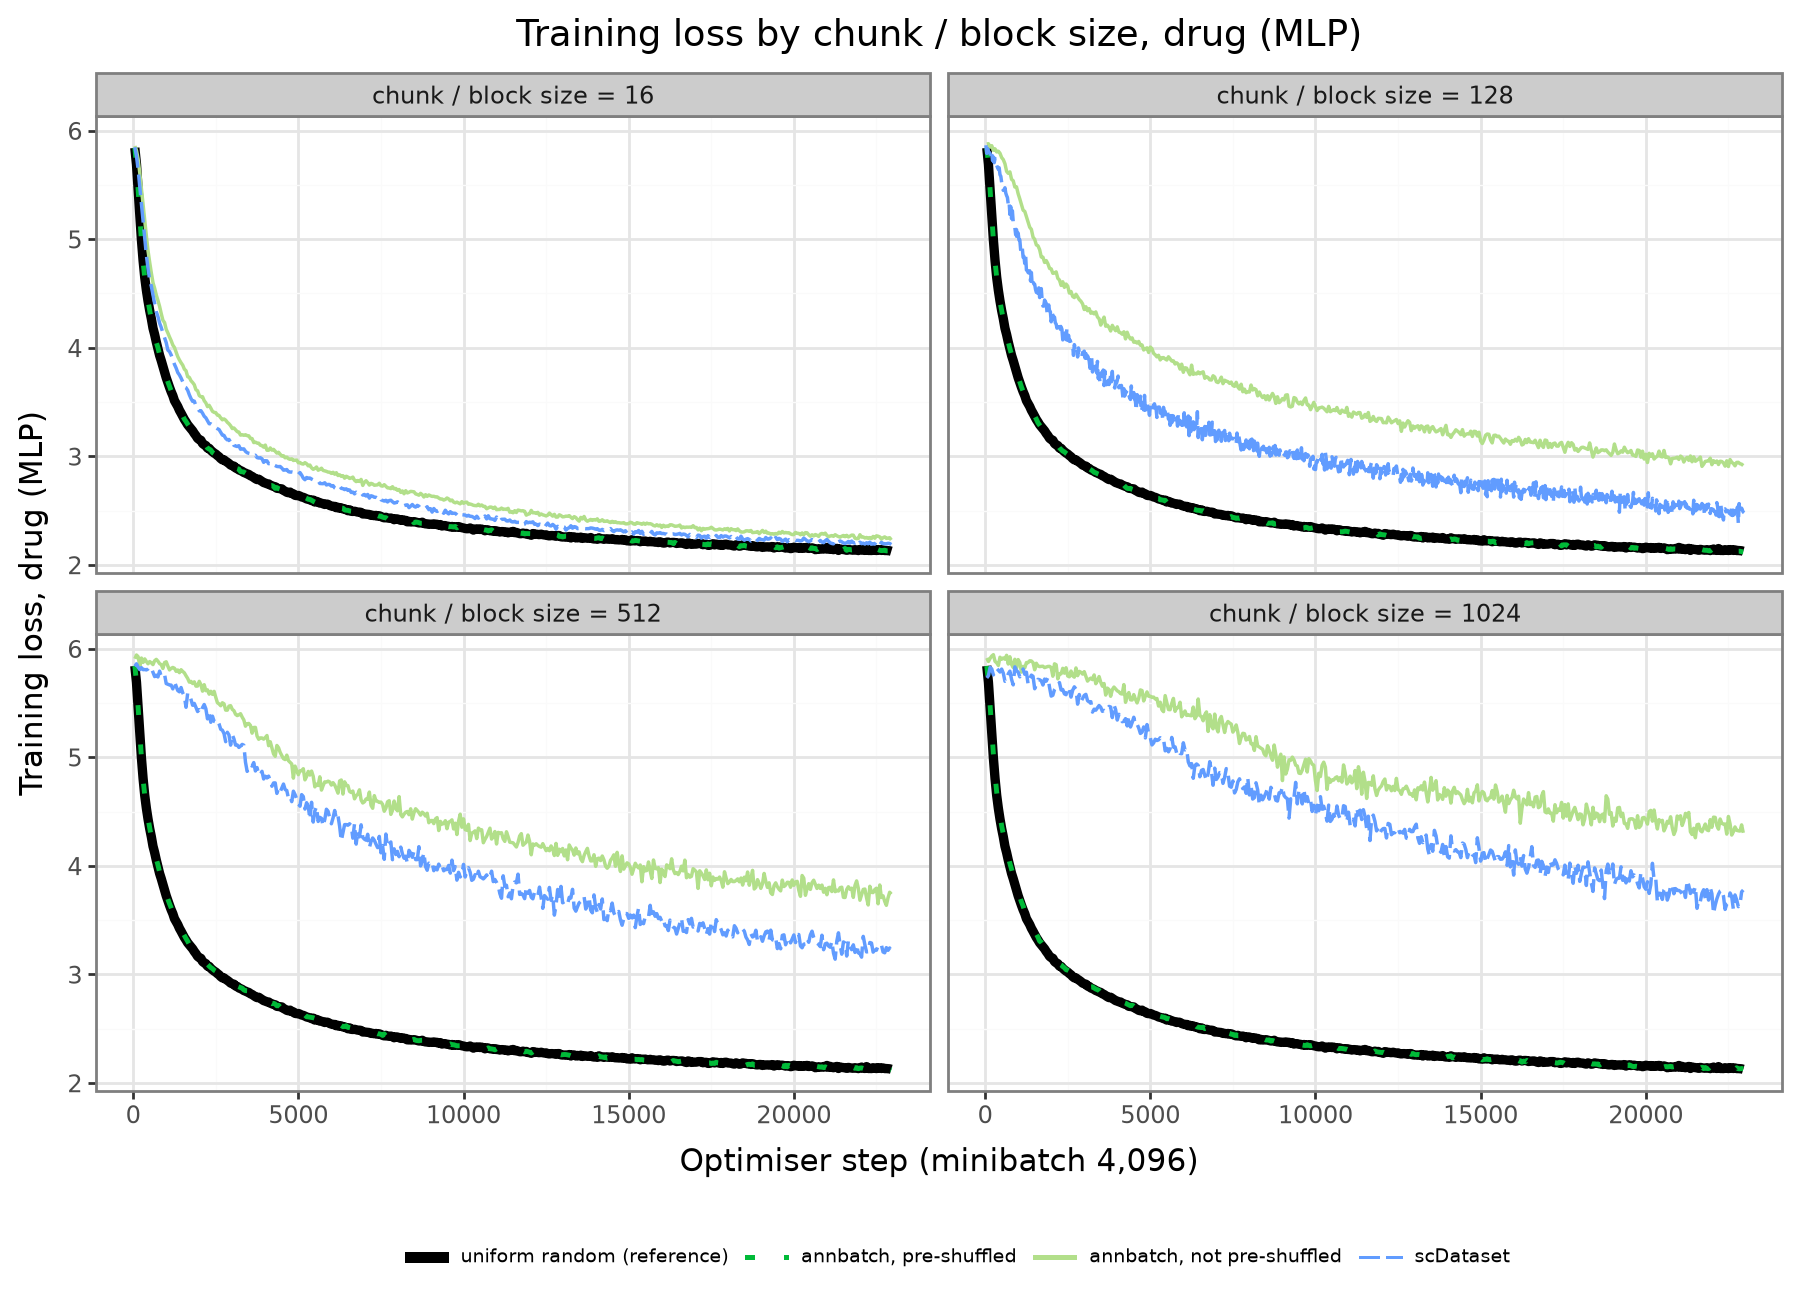

In [7]:
chunk6 = figures.figure6_chunk_sweep(head="mlp/drug")
p_chunk6 = figures.plot_figure6_chunk_sweep(chunk6)
figures.save(p_chunk6, "revision_fig6_chunk_sweep", width=9.0, height=6.5)
p_chunk6

In [8]:
figures.figure6_chunk_summary(head="mlp/drug").round(3)

,family,chunk_size,mean_abs_deviation,max_excursion,final_loss
5,"annbatch, not pre-shuffled",16.0,0.006,0.027,2.230
6,"annbatch, not pre-shuffled",128.0,0.018,0.073,2.915
7,"annbatch, not pre-shuffled",512.0,0.031,0.131,3.739
8,"annbatch, not pre-shuffled",1024.0,0.042,0.171,4.304
1,"annbatch, pre-shuffled",16.0,0.003,0.018,2.121
2,"annbatch, pre-shuffled",128.0,0.003,0.011,2.120
3,"annbatch, pre-shuffled",512.0,0.002,0.014,2.119
4,"annbatch, pre-shuffled",1024.0,0.003,0.014,2.130
9,scDataset,16.0,0.006,0.026,2.187
10,scDataset,128.0,0.030,0.151,2.480


* With pre-shuffling, chunk size can be raised to at least 1,024 at
  no measurable cost. Without it, degradation is already visible at 128.

In [9]:
tput = figures.throughput_chunk_table()
tput[tput.regime == "fixed_buffer"][
    ["loader", "block_size", "settings", "samples_per_sec", "sd", "n", "epoch_hours"]
].round(1)

,loader,block_size,settings,samples_per_sec,sd,n,epoch_hours
0,annbatch,1,"chunk_size=1, preload_nchunks=16384",6079.3,360.0,3,4.3
1,annbatch,16,"chunk_size=16, preload_nchunks=1024",38208.2,2212.9,3,0.7
2,annbatch,32,"chunk_size=32, preload_nchunks=512",40099.1,11013.5,3,0.7
3,annbatch,64,"chunk_size=64, preload_nchunks=256",45433.1,13877.5,3,0.6
4,annbatch,128,"chunk_size=128, preload_nchunks=128",65200.6,8710.1,3,0.4
5,annbatch,256,"chunk_size=256, preload_nchunks=64",71648.1,14373.3,3,0.4
6,annbatch,512,"chunk_size=512, preload_nchunks=32",78097.5,20527.5,3,0.3
7,annbatch,1024,"chunk_size=1024, preload_nchunks=16",96364.9,11686.2,3,0.3
8,annbatch,2048,"chunk_size=2048, preload_nchunks=8",100594.5,21667.0,3,0.3
9,annbatch,4096,"chunk_size=4096, preload_nchunks=4",106550.7,2157.5,3,0.2


wrote /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/annbatch_paper/revision/figures/revision_throughput_chunk_size.svg / .png


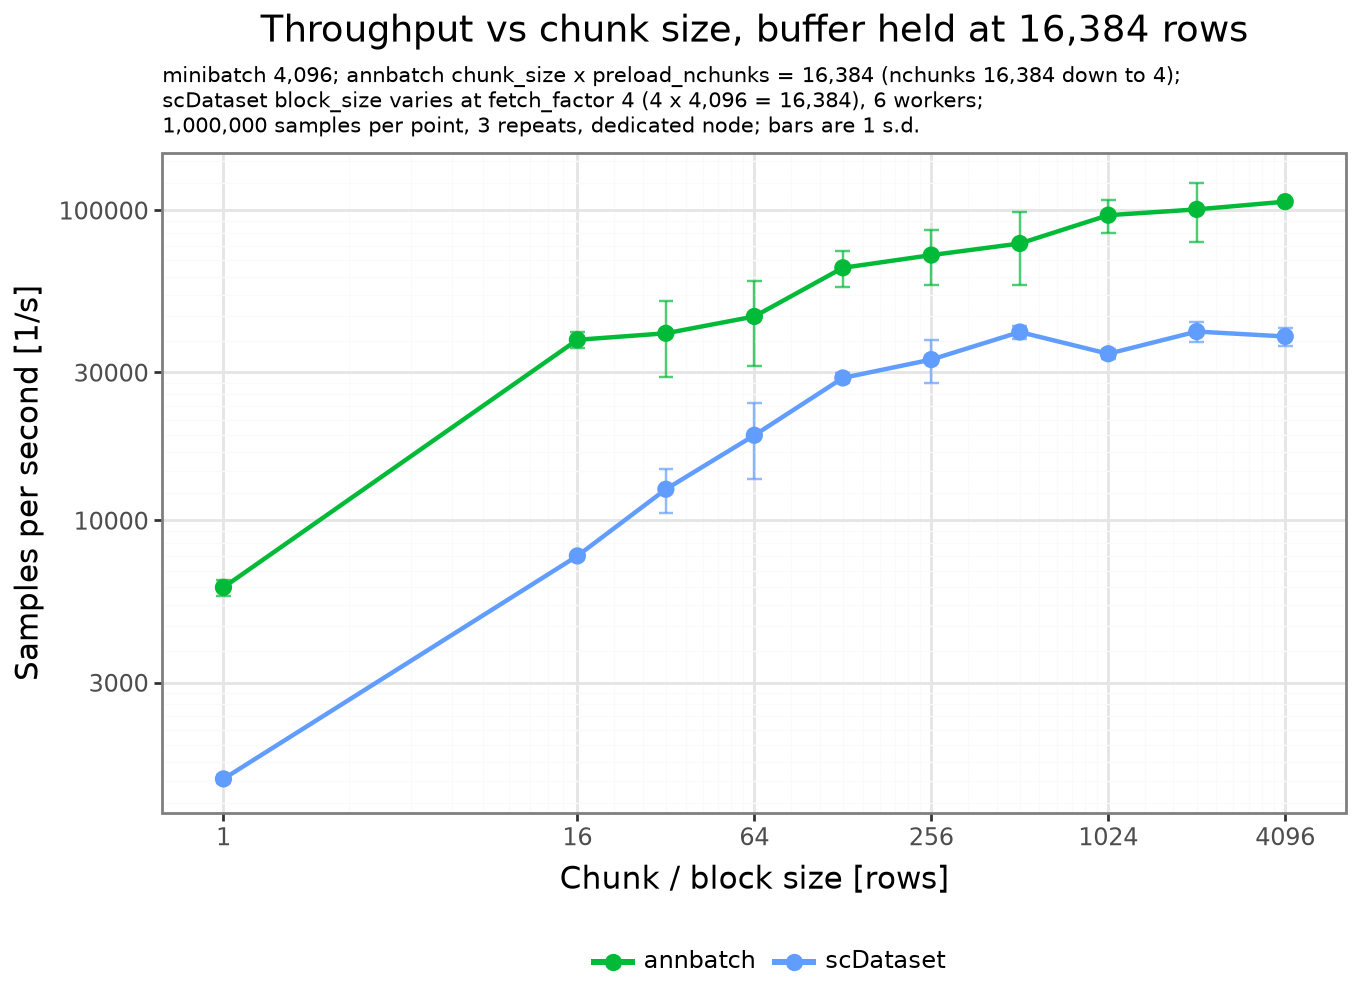

In [10]:
p_tput = figures.plot_throughput_chunk(tput)
figures.save(p_tput, "revision_throughput_chunk_size", width=6.8, height=5.0)
p_tput

## 3. R3 comment 3: guidance for choosing parameters

Parameter 1, `chunk_size` at load time: Minibatch label entropy measured over all 94,129,984 rows from the index

wrote /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/annbatch_paper/revision/figures/revision_diversity_drug.svg / .png


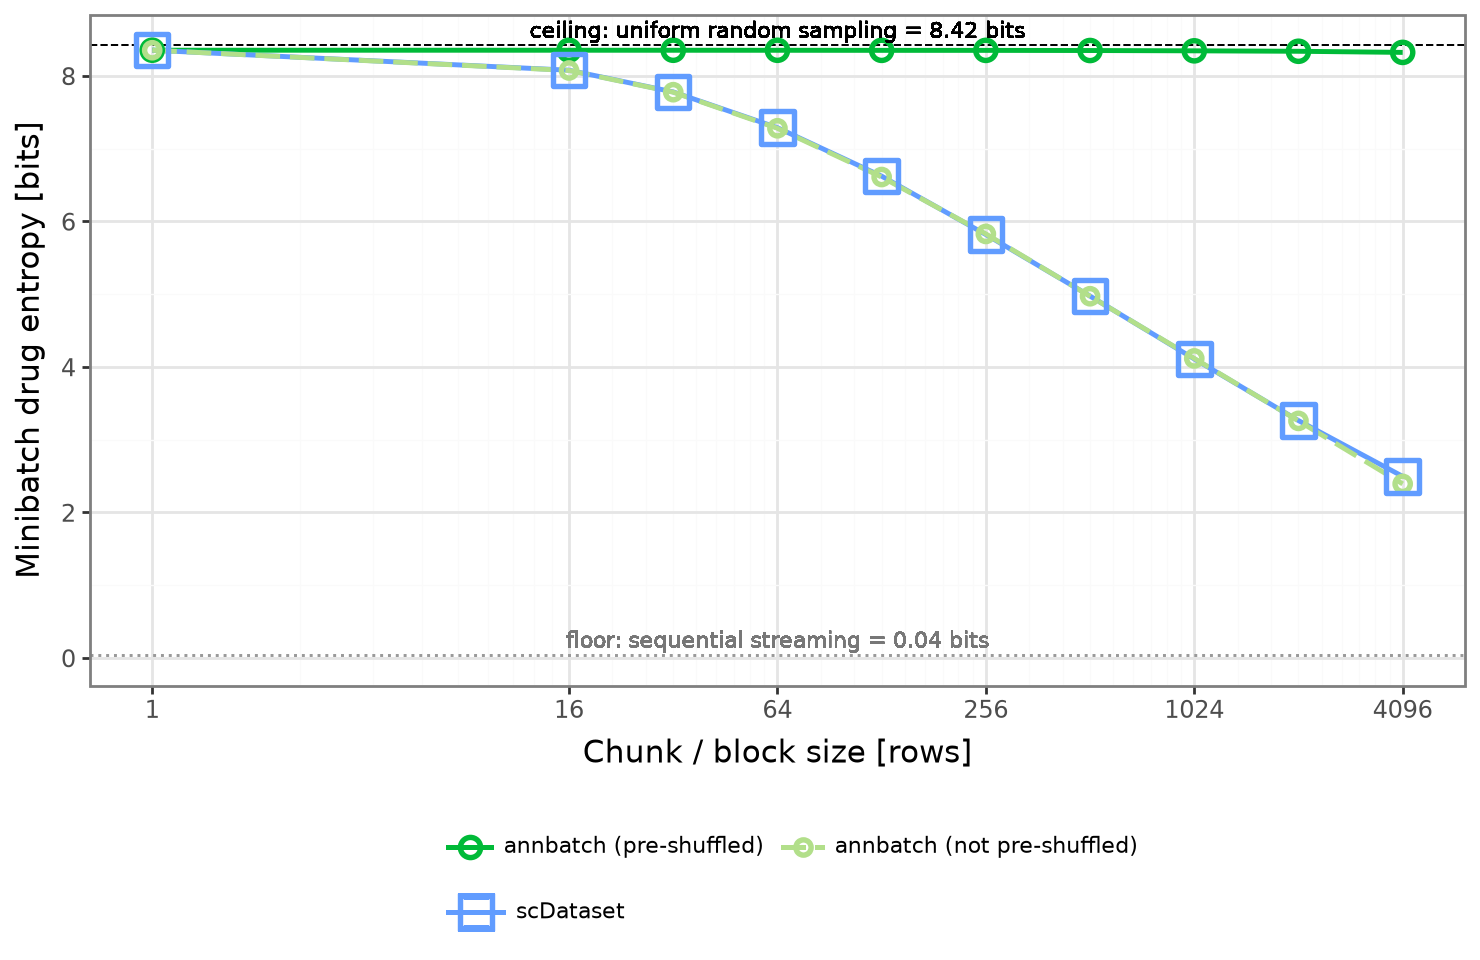

In [11]:
div = figures.diversity_table(
    {"unshuffled": "10_batch_diversity_unshuffled_buf16384.json",
     "preshuffled": "10_batch_diversity_preshuffled_buf16384.json"}, label="drug")
p_div = figures.plot_diversity(div, "drug")
figures.save(p_div, "revision_diversity_drug", width=7.4, height=4.8)
p_div

In [12]:
figures.diversity_agreement("drug")

family,block_size,annbatch (not pre-shuffled),scDataset,difference_bits
0,1.0,8.3519,8.3522,-0.0003
1,16.0,8.0741,8.0777,-0.0036
2,32.0,7.7755,7.7790,-0.0035
3,64.0,7.2797,7.2875,-0.0078
4,128.0,6.6096,6.6216,-0.0120
5,256.0,5.8277,5.8194,0.0083
6,512.0,4.9713,4.9735,-0.0021
7,1024.0,4.1166,4.1099,0.0067
8,2048.0,3.2582,3.2626,-0.0044
9,4096.0,2.3926,2.4953,-0.1027


In [13]:
struct = figures.ondisk_structure_table()
runs_drug = (struct[(struct.label == "drug") & (struct.window == 16)]
             [["plate", "n_categories_in_plate", "n_runs",
               "run_length_median", "run_length_max"]]
             .drop_duplicates("plate").sort_values("run_length_median"))
sorted_by_compound = runs_drug[runs_drug.run_length_median > 10_000]
print(f"{len(sorted_by_compound)} of {len(runs_drug)} plates sorted by compound: "
      f"median drug run {sorted_by_compound.run_length_median.min():,.0f} to "
      f"{sorted_by_compound.run_length_median.max():,.0f} cells")
print("the other two: " + ", ".join(
    f"{r.plate} {r.run_length_median:,.0f}"
    for r in runs_drug[runs_drug.run_length_median <= 10_000].itertuples()))
runs_drug.round(0)

12 of 14 plates sorted by compound: median drug run 53,650 to 229,114 cells
the other two: plate3 377, plate10 543


,plate,n_categories_in_plate,n_runs,run_length_median,run_length_max
54,plate3,93,8577,377.0,1298
243,plate10,95,6740,543.0,1624
216,plate9,380,68,53650.0,133734
162,plate7,380,69,53884.0,132869
0,plate1,380,67,62912.0,169857
270,plate11,380,54,67290.0,132798
108,plate5,380,59,67543.0,116684
351,plate14,380,60,69110.0,108978
81,plate4,380,55,71743.0,109565
135,plate6,380,51,79108.0,161362


In [14]:
mech = figures.diversity_table(
    {"unshuffled": "10_batch_diversity_unshuffled_buf16384.json"}, label="drug")
mech = mech[mech.family == "annbatch (not pre-shuffled)"].copy()
mech["chunks_in_buffer"] = mech.buffer_rows / mech.block_size
mech[["block_size", "buffer_rows", "chunks_in_buffer", "n_distinct"]].sort_values(
    "block_size").round(1)

,block_size,buffer_rows,chunks_in_buffer,n_distinct
3,1.0,16384.0,16384.0,379.7
4,16.0,16384.0,1024.0,341.1
5,32.0,16384.0,512.0,268.3
6,64.0,16384.0,256.0,179.6
7,128.0,16384.0,128.0,107.7
8,256.0,16384.0,64.0,61.1
9,512.0,16384.0,32.0,33.9
10,1024.0,16384.0,16.0,19.6
11,2048.0,16384.0,8.0,12.1
12,4096.0,16384.0,4.0,8.0


* Degradation when `chunk_size` approaches the
  on-disk run length of the label, and the recoverable
  diversity is bounded by `buffer_rows / chunk_size`.
* Pre-shuffling sets the run length to 1 and removes the constraint.

Parameter 2: `shuffle_chunk_size` (pre-shuffling)

* Conclusion: `dataset_size / shuffle_chunk_size` above about 2,000 and minibatch entropy stays within 1% of a perfect shuffle (annbatch's default: 2^21 / 1,000 = 2,097)

In [15]:
pq = figures.preshuffle_quality_table()
print(f"ideal entropy: {pq.attrs['ideal']:.3f} bits; "
      f"shipped shuffle_chunk_size: {pq.attrs['shipped']:,}")
# ratio as an integer: pandas renders it in scientific notation otherwise, and
# the "above about 2,000" rule then has no row a reader can point at.
pq = pq.assign(ratio=pq.ratio.round(0).astype("int64"))
pq[["shuffle_chunk_size", "ratio", "loader_chunk_size",
    "entropy", "fraction_of_ideal"]].round(4)

ideal entropy: 8.420 bits; shipped shuffle_chunk_size: 1,000


,shuffle_chunk_size,ratio,loader_chunk_size,entropy,fraction_of_ideal
0,1,2097152,512,8.3523,0.9919
1,1,2097152,1024,8.3518,0.9919
2,10,209715,512,8.3517,0.9919
3,10,209715,1024,8.3520,0.9919
4,100,20972,512,8.3518,0.9919
5,100,20972,1024,8.3514,0.9918
6,1000,2097,512,8.3478,0.9914
7,1000,2097,1024,8.3437,0.9909
8,10000,210,512,8.3195,0.9880
9,10000,210,1024,8.2846,0.9839


* scDataset: high throughput only at large blocks, but large blocks -> low diversity

In [16]:
tr = figures.speed_diversity_tradeoff("drug")
print(f"diversity ceiling: {tr.attrs['ceiling_bits']:.2f} bits")
tr.round(2)

diversity ceiling: 8.42 bits


,block_size,scDataset samples/s,scDataset drug entropy,annbatch samples/s,annbatch (pre-shuffled) drug entropy
0,1,1466.77,8.35,6079.32,8.35
1,16,7679.18,8.08,38208.20,8.35
2,32,12599.53,7.78,40099.09,8.35
3,64,18805.38,7.29,45433.07,8.35
4,128,28783.41,6.62,65200.60,8.35
5,256,32985.75,5.82,71648.09,8.35
6,512,40478.94,4.97,78097.50,8.35
7,1024,34443.39,4.11,96364.92,8.34
8,2048,40620.30,3.26,100594.49,8.34
9,4096,39161.87,2.50,106550.65,8.32


### Few-epoch training (R2 major 5)

* Only one epoch (scvi-tools default for a dataset the size of TAHOE-100M with a warning): only on-disk order, no later passes over which to average out a biased slice

In [17]:
# scvi-tools' own default: min(round((20000 / n_obs) * 400), 400), floored at 1.
_n_obs = 94_129_984
_budget = 20_000 * 400
_epochs_asked = _budget / _n_obs
print(f"constant sample budget      {_budget:,} observations")
print(f"training cells              {_n_obs:,}")
print(f"epochs that budget implies  {_epochs_asked:.3f}")
print(f"max_epochs after floor      {max(1, min(round(_epochs_asked), 400))}")

constant sample budget      8,000,000 observations
training cells              94,129,984
epochs that budget implies  0.085
max_epochs after floor      1


In [18]:
pe = figures.partial_epoch_table()
print(pe.attrs["what"])
pe[[c for c in pe.columns if "/ random" not in c]].round(4)

drug macro_f1 on val_iid (MLP head, seed 0), at the checkpoint nearest each fraction of one epoch


,fraction_of_epoch,optimiser_step,random sampling,"annbatch, pre-shuffled (chunk 1024)","annbatch, not pre-shuffled (chunk 1024)","scDataset (block 16, fetch 4)",streaming
0,0.05,1000,0.1817,0.1749,0.0002,0.1209,0.0000
1,0.10,2500,0.3055,0.3009,0.0002,0.2492,0.0000
2,0.25,5500,0.3854,0.3859,0.0032,0.3402,0.0000
3,0.50,11500,0.4411,0.4404,0.0211,0.4111,0.0001
4,1.00,22980,0.4735,0.4728,0.0636,0.4495,0.0001


In [19]:
# The same, divided by the random-sampling column of the table above.
pe[["fraction_of_epoch", "optimiser_step"]
   + [c for c in pe.columns if "/ random" in c]]

,fraction_of_epoch,optimiser_step,"annbatch, pre-shuffled (chunk 1024) / random","annbatch, not pre-shuffled (chunk 1024) / random","scDataset (block 16, fetch 4) / random",streaming / random
0,0.05,1000,0.963,0.001,0.666,0.0
1,0.10,2500,0.985,0.001,0.816,0.0
2,0.25,5500,1.001,0.008,0.883,0.0
3,0.50,11500,0.998,0.048,0.932,0.0
4,1.00,22980,0.998,0.134,0.949,0.0


## 4. R2 minor 3: the memmap baseline

* One `uint8` array, 64 GB memory limit. 
* Four variants:
  1. `random_row_manuscript` is the published baseline: one row per sample
     request with `DataLoader(shuffle=True)`; the `float32` cast happens in the
     worker, so 614 MB crosses the IPC boundary per batch of 128.
  2. `random_row` is the same access pattern in-process, with no IPC.
  3. `block_shuffled` mirrors `annbatch.samplers.RandomSampler`; the fair
     like-for-like comparison.
  4. `sequential` is streaming in on-disk order; the hardware upper bound.

In [20]:
# The array, its cache oversubscription, and what the float32 cast costs per batch.
import json
_mm = json.loads((RESULTS / "40_wgs_memmap_baselines_bs128.json").read_text())
_n_obs = _mm["results"][0]["params"]["n_obs"]
_n_var = json.loads((RESULTS / "41_wgs_preshuffle_common.json").read_text())["n_var"]
_batch = _mm["batch_size"]
_bytes = _n_obs * _n_var
_limit = 64 * 1000 ** 3
print(f"array            {_n_obs:,} x {_n_var:,} uint8 = {_bytes / 1024 ** 3:,.0f} GiB")
print(f"memory limit     {_limit / 1000 ** 3:.0f} GB -> {_bytes / _limit:.1f}x oversubscribed, "
      f"at most {100 * _limit / _bytes:.0f}% cacheable")
print(f"float32 per batch of {_batch}: {_batch * _n_var * 4 / 1e6:,.0f} MB across the IPC boundary")

array            502,714 x 1,200,000 uint8 = 562 GiB
memory limit     64 GB -> 9.4x oversubscribed, at most 11% cacheable
float32 per batch of 128: 614 MB across the IPC boundary


In [21]:
mm = figures.memmap_table()
p_mm = figures.plot_memmap(mm)
figures.save(p_mm, "revision_wgs_memmap_baselines", width=7.0, height=4.2)
mm.round(1)

/lustre/groups/ml01/workspace/lucas.arnoldt/annbatch_rev/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


/lustre/groups/ml01/workspace/lucas.arnoldt/annbatch_rev/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


wrote /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/annbatch_paper/revision/figures/revision_wgs_memmap_baselines.svg / .png


,mode,access,samples_per_sec,sd
3,random_row_manuscript,"single row per __getitem__ cast to float32, un...",39.0,0.3
2,random_row,"uniform random single-row reads, in-process, u...",60.2,0.5
1,block_shuffled,"random contiguous blocks, shuffled in memory",279.5,2.5
4,sequential,"on-disk order, no randomisation (upper bound o...",495.4,2.1
0,annbatch,random contiguous chunks from pre-shuffled Zar...,1493.3,11.2


## 5. R2 major 6: pre-shuffling wall-clock for all benchmarks

In [22]:
figures.wgs_preshuffle_table().round(3)

,regime,n_variants,sparse,input_GiB,output_GiB,preshuffle_hours,host,cpu
0,common,1200000,False,89.179,256.867,7.694,cpusrv64.scidom.de,Intel(R) Xeon(R) Gold 6248R CPU @ 3.00GHz
1,rare_maf_0.01,92087087,True,261.875,250.434,3.406,cpusrv130.scidom.de,AMD EPYC 9745 128-Core Processor
2,rare_maf_0.001,74589081,True,70.572,64.712,0.700,cpusrv130.scidom.de,AMD EPYC 9745 128-Core Processor


In [23]:
import pandas as pd
pd.DataFrame([figures.microscopy_preshuffle()]).round(2)

,n_inputs,input_GiB,output_GiB,preshuffle_hours,layout,host,cpu
0,5,60.39,61.77,1.5,"{'n_obs_per_chunk': 64, 'shard_size': 32768, '...",cpusrv23.scidom.de,Intel(R) Xeon(R) Gold 6248R CPU @ 3.00GHz
